# Évaluation des Modèles - Détection de Faux Avis

Évaluation approfondie des modèles entraînés.

## Imports et Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# Imports Sklearn
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss
)
from sklearn.calibration import calibration_curve

# Configuration
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Tous les imports réussis !")

All imports successful!


## Charger les données et les modèles

In [ ]:
print("=" * 80)
print("CHARGEMENT DES DONNÉES ET MODÈLES")
print("=" * 80)

# Charger les données
df = pd.read_csv('../data/processed/features_extracted.csv')
print(f"\nDataset chargé : {df.shape}")

# Charger le modèle et les artefacts sauvegardés
models_dir = Path('../models')

best_model = joblib.load(models_dir / 'best_rf_model.joblib')
scaler = joblib.load(models_dir / 'scaler.joblib')
feature_cols = joblib.load(models_dir / 'feature_columns.joblib')

print(f"Meilleur modèle chargé : {type(best_model).__name__}")
print(f"Scaler chargé : {type(scaler).__name__}")
print(f"Caractéristiques chargées : {len(feature_cols)} caractéristiques")

LOADING DATA AND MODELS

Dataset loaded: (13351, 42)
Best model loaded: RandomForestClassifier
Scaler loaded: StandardScaler
Features loaded: 21 features


In [ ]:
# Préparer X et y
X = df[feature_cols].copy()
y = df['is_real'].copy()

# Gérer les valeurs manquantes
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())

# Division Entraînement/Test (identique à l'entraînement)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDonnées préparées :")
print(f"  Entraînement : {X_train.shape[0]} échantillons")
print(f"  Test : {X_test.shape[0]} échantillons")


Data prepared:
  Train: 10680 samples
  Test: 2671 samples


## Métriques Complètes

In [ ]:
print("=" * 80)
print("MÉTRIQUES COMPLÈTES")
print("=" * 80)

# Prédictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Calculer toutes les métriques
metrics = {
    'Exactitude': accuracy_score(y_test, y_pred),
    'Exactitude Équilibrée': balanced_accuracy_score(y_test, y_pred),
    'Précision': precision_score(y_test, y_pred),
    'Rappel (Sensibilité)': recall_score(y_test, y_pred),
    'Spécificité': recall_score(y_test, y_pred, pos_label=0),
    'Score F1': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
    'Précision Moyenne': average_precision_score(y_test, y_proba),
    'Coef Corr Matthews': matthews_corrcoef(y_test, y_pred),
    'Kappa de Cohen': cohen_kappa_score(y_test, y_pred),
    'Log Loss': log_loss(y_test, y_proba),
    'Score de Brier': brier_score_loss(y_test, y_proba)
}

print("\nTOUTES LES MÉTRIQUES D'ÉVALUATION :")
print("-" * 40)
for metric, value in metrics.items():
    print(f"  {metric:25s}: {value:.4f}")

# Sauvegarder les métriques
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Métrique', 'Valeur'])
metrics_df.to_csv('../outputs/evaluation_metrics.csv', index=False)
print("\nMétriques sauvegardées dans outputs/evaluation_metrics.csv")

COMPREHENSIVE METRICS

ALL EVALUATION METRICS:
----------------------------------------
  Accuracy                 : 0.9940
  Balanced Accuracy        : 0.9929
  Precision                : 0.9982
  Recall (Sensitivity)     : 0.9946
  Specificity              : 0.9911
  F1-Score                 : 0.9964
  ROC-AUC                  : 0.9993
  Average Precision        : 0.9999
  Matthews Corr Coef       : 0.9788
  Cohen Kappa              : 0.9788
  Log Loss                 : 0.0271
  Brier Score              : 0.0067

Metrics saved to outputs/evaluation_metrics.csv


## Analyse de Validation Croisée

CROSS-VALIDATION ANALYSIS

Running 10-Fold Cross-Validation...
  accuracy    : 0.9919 (+/- 0.0054)
  precision   : 0.9985 (+/- 0.0020)
  recall      : 0.9918 (+/- 0.0065)
  f1          : 0.9951 (+/- 0.0033)
  roc_auc     : 0.9995 (+/- 0.0007)


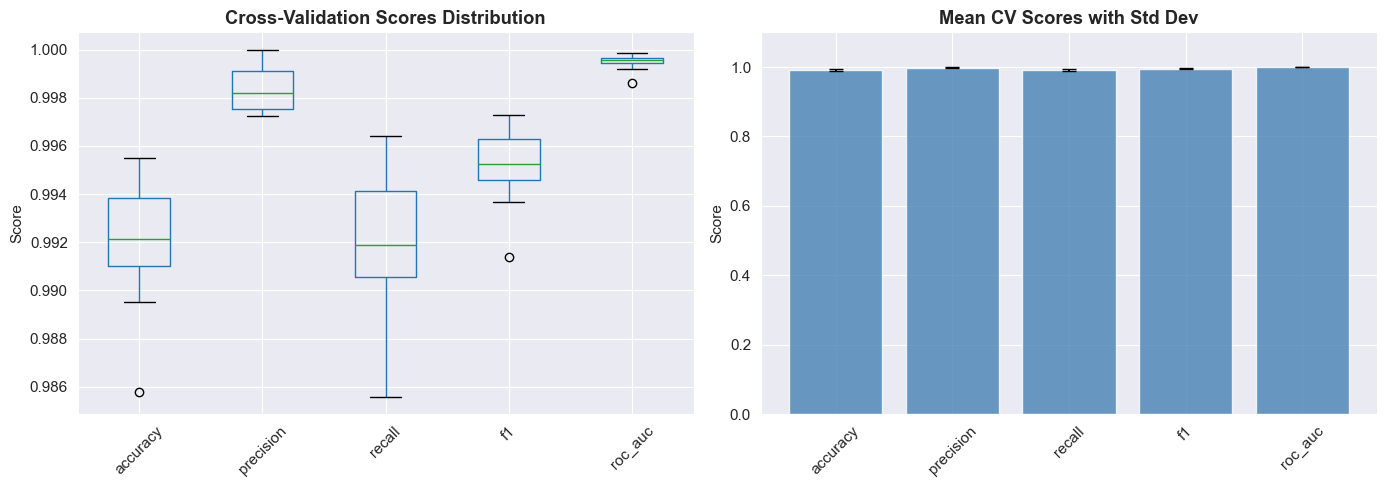


CV analysis saved!


In [ ]:
print("=" * 80)
print("ANALYSE DE VALIDATION CROISÉE")
print("=" * 80)

# K-Fold Stratifié
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Métriques de scoring multiples
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("\nExécution de la validation croisée 10-Fold...")
cv_results = {}

for metric in scoring_metrics:
    scores = cross_val_score(best_model, X, y, cv=cv, scoring=metric, n_jobs=-1)
    cv_results[metric] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"  {metric:12s}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Visualiser les résultats CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diagramme en boîte des scores CV
cv_df = pd.DataFrame({m: cv_results[m]['scores'] for m in scoring_metrics})
cv_df.boxplot(ax=axes[0])
axes[0].set_title('Distribution des Scores de Validation Croisée', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

# Scores moyens avec barres d'erreur
means = [cv_results[m]['mean'] for m in scoring_metrics]
stds = [cv_results[m]['std'] for m in scoring_metrics]
x_pos = np.arange(len(scoring_metrics))

axes[1].bar(x_pos, means, yerr=stds, capsize=5, color='steelblue', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(scoring_metrics, rotation=45)
axes[1].set_ylabel('Score')
axes[1].set_title('Scores CV Moyens avec Écart-Type', fontweight='bold')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('../outputs/13_cv_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAnalyse CV sauvegardée !")

## Courbes d'Apprentissage

LEARNING CURVES

Generating learning curves (this may take a minute)...


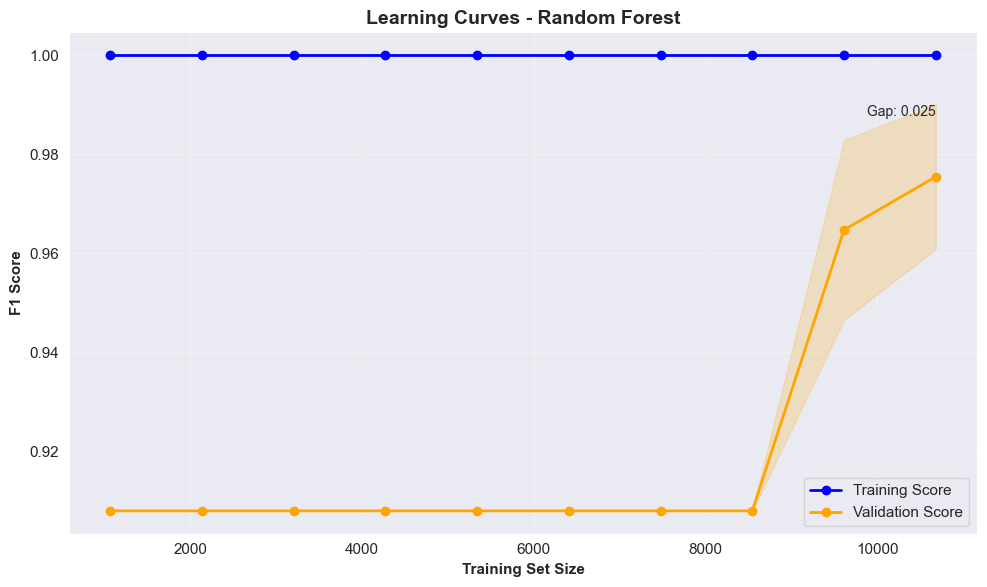


Learning Curve Analysis:
  Final Training Score: 1.0000
  Final Validation Score: 0.9754
  Gap (Overfitting indicator): 0.0246
  -> Model has LOW overfitting (good generalization)


In [ ]:
print("=" * 80)
print("COURBES D'APPRENTISSAGE")
print("=" * 80)

print("\nGénération des courbes d'apprentissage (cela peut prendre une minute)...")

# Calculer les courbes d'apprentissage
train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, test_scores = learning_curve(
    best_model, X, y,
    train_sizes=train_sizes,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# Calculer moyenne et écart-type
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Tracer
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
ax.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.2, color='orange')
ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Score Entraînement', linewidth=2)
ax.plot(train_sizes_abs, test_mean, 'o-', color='orange', label='Score Validation', linewidth=2)

ax.set_xlabel('Taille de l\'ensemble d\'entraînement', fontweight='bold')
ax.set_ylabel('Score F1', fontweight='bold')
ax.set_title('Courbes d\'Apprentissage - Forêt Aléatoire', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Ajouter annotation
gap = train_mean[-1] - test_mean[-1]
ax.annotate(f'Écart: {gap:.3f}', xy=(train_sizes_abs[-1], (train_mean[-1] + test_mean[-1])/2),
            fontsize=10, ha='right')

plt.tight_layout()
plt.savefig('../outputs/14_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAnalyse des courbes d'apprentissage :")
print(f"  Score d'entraînement final : {train_mean[-1]:.4f}")
print(f"  Score de validation final : {test_mean[-1]:.4f}")
print(f"  Écart (indicateur de surapprentissage) : {gap:.4f}")

if gap < 0.05:
    print("  -> Le modèle a un FAIBLE surapprentissage (bonne généralisation)")
elif gap < 0.1:
    print("  -> Le modèle a un surapprentissage MODÉRÉ")
else:
    print("  -> Le modèle a un FORT surapprentissage (considérer la régularisation)")

## Courbe Précision-Rappel

PRECISION-RECALL ANALYSIS


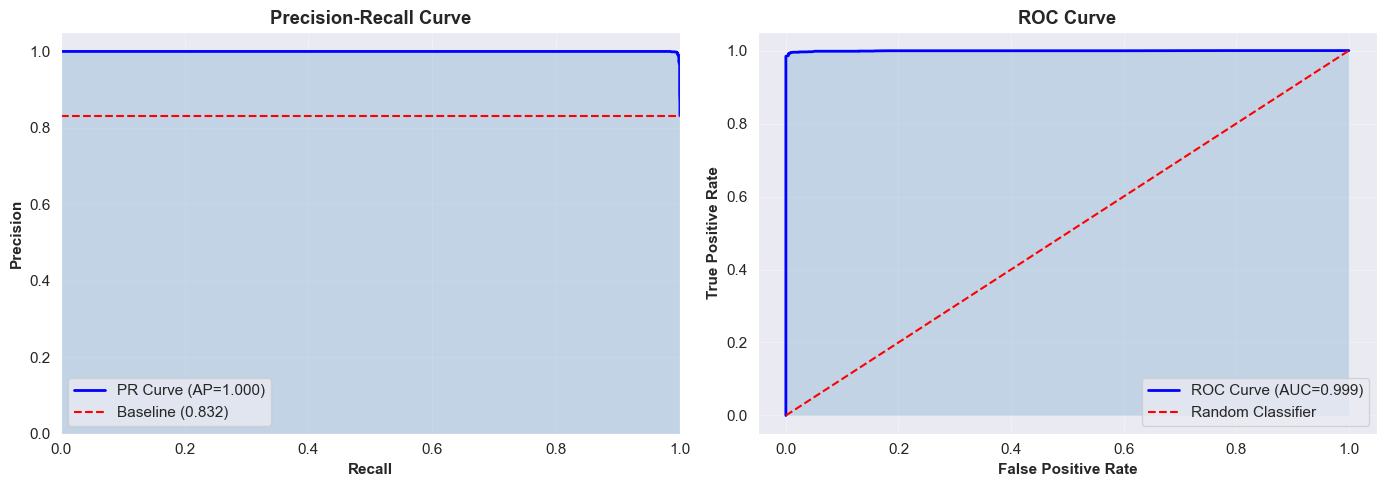


Average Precision: 0.9999
ROC-AUC: 0.9993


In [ ]:
print("=" * 80)
print("ANALYSE PRÉCISION-RAPPEL")
print("=" * 80)

# Calculer la courbe précision-rappel
precision_curve, recall_curve_vals, thresholds_pr = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

# Calculer la courbe ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Tracer les deux courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe Précision-Rappel
axes[0].plot(recall_curve_vals, precision_curve, 'b-', linewidth=2,
             label=f'Courbe PR (AP={avg_precision:.3f})')
axes[0].axhline(y=y_test.mean(), color='r', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
axes[0].fill_between(recall_curve_vals, precision_curve, alpha=0.2)
axes[0].set_xlabel('Rappel', fontweight='bold')
axes[0].set_ylabel('Précision', fontweight='bold')
axes[0].set_title('Courbe Précision-Rappel', fontweight='bold')
axes[0].legend(loc='lower left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# Courbe ROC avec plus de détails
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Courbe ROC (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', label='Classifieur Aléatoire')
axes[1].fill_between(fpr, tpr, alpha=0.2)
axes[1].set_xlabel('Taux de Faux Positifs', fontweight='bold')
axes[1].set_ylabel('Taux de Vrais Positifs', fontweight='bold')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/15_pr_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPrécision Moyenne : {avg_precision:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")

## Analyse des Seuils

THRESHOLD ANALYSIS

Optimal Thresholds:
  By F1-Score: 0.45
  By Youden's J (ROC): 0.57


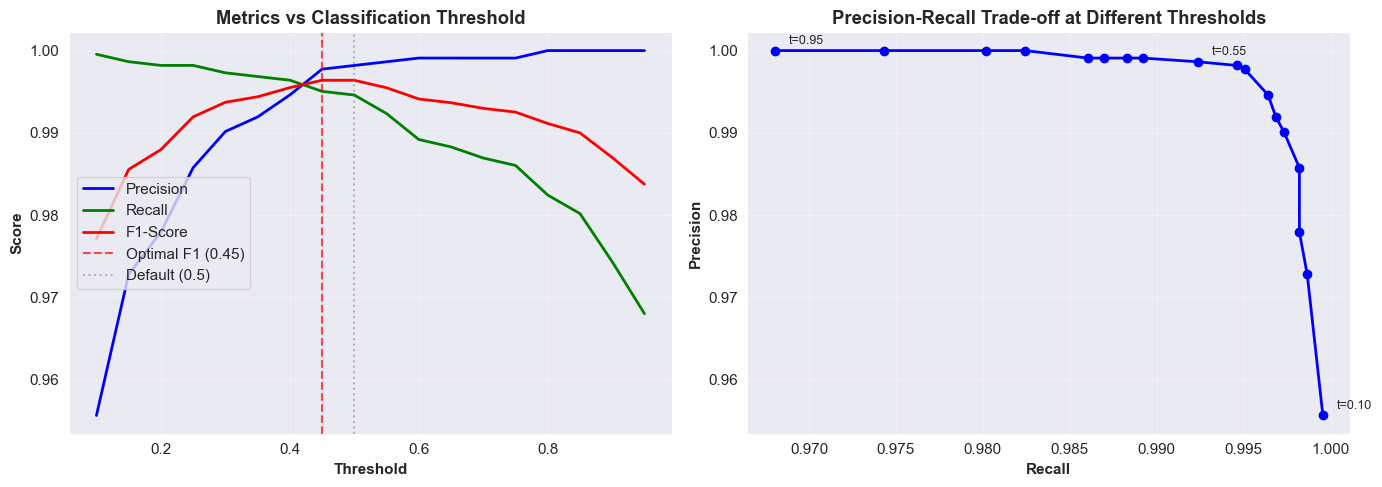


Threshold Analysis Table:


,Threshold,Accuracy,Precision,Recall,F1-Score,Specificity
0,0.10,0.9611,0.9557,0.9995,0.9771,0.7711
1,0.15,0.9757,0.9728,0.9986,0.9856,0.8622
2,0.20,0.9798,0.9779,0.9982,0.9880,0.8889
3,0.25,0.9865,0.9858,0.9982,0.9919,0.9289
4,0.30,0.9895,0.9902,0.9973,0.9937,0.9511
5,0.35,0.9906,0.9919,0.9968,0.9944,0.9600
6,0.40,0.9925,0.9946,0.9964,0.9955,0.9733
7,0.45,0.9940,0.9977,0.9950,0.9964,0.9889
8,0.50,0.9940,0.9982,0.9946,0.9964,0.9911
9,0.55,0.9925,0.9986,0.9923,0.9955,0.9933


In [ ]:
print("=" * 80)
print("ANALYSE DES SEUILS")
print("=" * 80)

# Calculer les métriques à différents seuils
thresholds = np.arange(0.1, 1.0, 0.05)
threshold_metrics = []

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    threshold_metrics.append({
        'Seuil': thresh,
        'Exactitude': accuracy_score(y_test, y_pred_thresh),
        'Précision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'Rappel': recall_score(y_test, y_pred_thresh, zero_division=0),
        'Score-F1': f1_score(y_test, y_pred_thresh, zero_division=0),
        'Spécificité': recall_score(y_test, y_pred_thresh, pos_label=0, zero_division=0)
    })

thresh_df = pd.DataFrame(threshold_metrics)

# Trouver les seuils optimaux
optimal_f1_idx = thresh_df['Score-F1'].idxmax()
optimal_f1_thresh = thresh_df.loc[optimal_f1_idx, 'Seuil']

# Statistique J de Youden (TPR - FPR) pour le seuil ROC optimal
j_scores = tpr - fpr
optimal_roc_idx = np.argmax(j_scores)
optimal_roc_thresh = thresholds_roc[optimal_roc_idx]

print(f"\nSeuils Optimaux :")
print(f"  Par Score-F1 : {optimal_f1_thresh:.2f}")
print(f"  Par J de Youden (ROC) : {optimal_roc_thresh:.2f}")

# Tracer l'analyse des seuils
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Métriques vs Seuil
axes[0].plot(thresh_df['Seuil'], thresh_df['Précision'], 'b-', label='Précision', linewidth=2)
axes[0].plot(thresh_df['Seuil'], thresh_df['Rappel'], 'g-', label='Rappel', linewidth=2)
axes[0].plot(thresh_df['Seuil'], thresh_df['Score-F1'], 'r-', label='Score-F1', linewidth=2)
axes[0].axvline(x=optimal_f1_thresh, color='red', linestyle='--', alpha=0.7, 
                label=f'F1 Optimal ({optimal_f1_thresh:.2f})')
axes[0].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5, label='Par défaut (0.5)')

axes[0].set_xlabel('Seuil', fontweight='bold')
axes[0].set_ylabel('Score', fontweight='bold')
axes[0].set_title('Métriques vs Seuil de Classification', fontweight='bold')
axes[0].legend(loc='center left')
axes[0].grid(True, alpha=0.3)

# Compromis Précision-Rappel
axes[1].plot(thresh_df['Rappel'], thresh_df['Précision'], 'b-o', linewidth=2, markersize=6)

# Annoter quelques points
for i in [0, len(thresh_df)//2, len(thresh_df)-1]:
    axes[1].annotate(f's={thresh_df.iloc[i]["Seuil"]:.2f}', 
                     (thresh_df.iloc[i]['Rappel'], thresh_df.iloc[i]['Précision']),
                     textcoords="offset points", xytext=(10,5), fontsize=9)

axes[1].set_xlabel('Rappel', fontweight='bold')
axes[1].set_ylabel('Précision', fontweight='bold')
axes[1].set_title('Compromis Précision-Rappel à Différents Seuils', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/16_threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Afficher le tableau des seuils
print("\nTableau d'Analyse des Seuils :")
display(thresh_df.round(4))

## Analyse de Calibration

CALIBRATION ANALYSIS


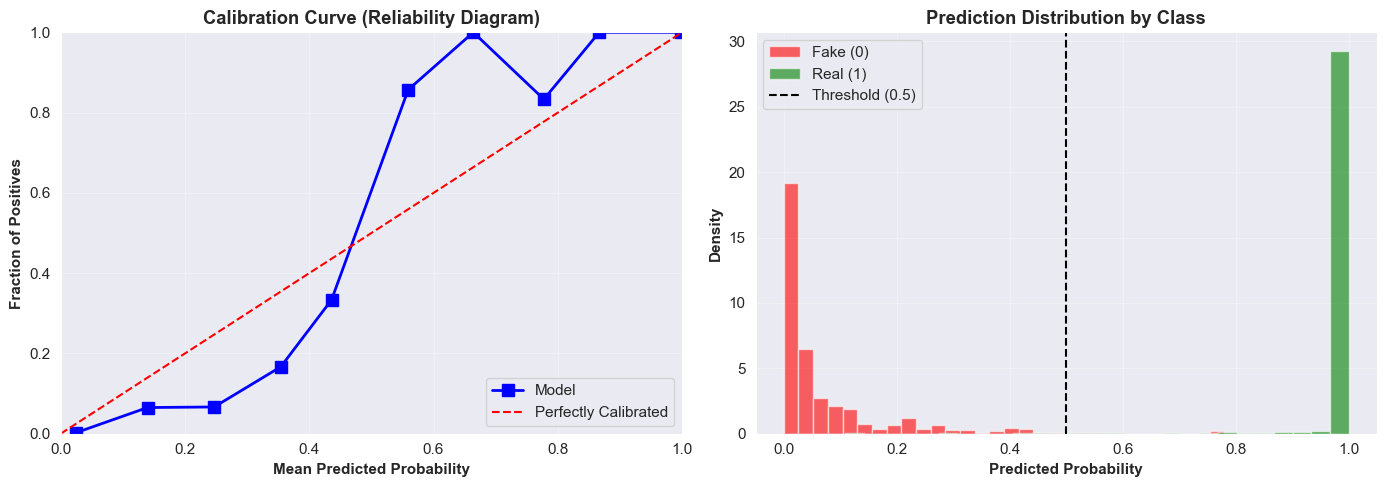


Brier Score: 0.0067 (lower is better, 0 is perfect)
  -> Model is WELL calibrated


In [ ]:
print("=" * 80)
print("ANALYSE DE CALIBRATION")
print("=" * 80)

# Calculer la courbe de calibration
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')

# Tracer la courbe de calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de calibration
axes[0].plot(prob_pred, prob_true, 's-', color='blue', linewidth=2, markersize=8, label='Modèle')
axes[0].plot([0, 1], [0, 1], 'r--', label='Parfaitement Calibré')
axes[0].set_xlabel('Probabilité Prédite Moyenne', fontweight='bold')
axes[0].set_ylabel('Fraction de Positifs', fontweight='bold')
axes[0].set_title('Courbe de Calibration (Diagramme de Fiabilité)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Distribution des prédictions
axes[1].hist(y_proba[y_test == 0], bins=30, alpha=0.6, label='Faux (0)', color='red', density=True)
axes[1].hist(y_proba[y_test == 1], bins=30, alpha=0.6, label='Réel (1)', color='green', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Seuil (0.5)')
axes[1].set_xlabel('Probabilité Prédite', fontweight='bold')
axes[1].set_ylabel('Densité', fontweight='bold')
axes[1].set_title('Distribution des Prédictions par Classe', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/17_calibration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAnalyse de calibration sauvegardée !")

## Analyse des Erreurs

In [ ]:
print("=" * 80)
print("ANALYSE DES ERREURS")
print("=" * 80)

# Créer le DataFrame d'évaluation
eval_df = X_test.copy()
eval_df['y_true'] = y_test.values
eval_df['y_pred'] = y_pred
eval_df['y_proba'] = y_proba
eval_df['correct'] = eval_df['y_true'] == eval_df['y_pred']

# Classifier les prédictions
eval_df['type_prediction'] = 'Inconnu'
eval_df.loc[(eval_df['y_true'] == 1) & (eval_df['y_pred'] == 1), 'type_prediction'] = 'Vrai Positif'
eval_df.loc[(eval_df['y_true'] == 0) & (eval_df['y_pred'] == 0), 'type_prediction'] = 'Vrai Négatif'
eval_df.loc[(eval_df['y_true'] == 0) & (eval_df['y_pred'] == 1), 'type_prediction'] = 'Faux Positif'
eval_df.loc[(eval_df['y_true'] == 1) & (eval_df['y_pred'] == 0), 'type_prediction'] = 'Faux Négatif'

# Compter les erreurs
error_counts = eval_df['type_prediction'].value_counts()
print("\nDistribution des Types de Prédiction :")
for pred_type, count in error_counts.items():
    pct = count / len(eval_df) * 100
    print(f"  {pred_type:15s}: {count:5d} ({pct:.1f}%)")

# Visualisation de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nDétails de la Matrice de Confusion :")
print(f"  Vrais Négatifs (Faux correctement identifiés) : {tn}")
print(f"  Faux Positifs (Faux classés comme Réels) : {fp}")
print(f"  Faux Négatifs (Réels classés comme Faux) : {fn}")
print(f"  Vrais Positifs (Réels correctement identifiés) : {tp}")

ERROR ANALYSIS

Prediction Type Distribution:
  True Positive  :  2209 (82.7%)
  True Negative  :   446 (16.7%)
  False Negative :    12 (0.4%)
  False Positive :     4 (0.1%)

Confusion Matrix Breakdown:
  True Negatives (correctly identified Fake): 446
  False Positives (Fake classified as Real): 4
  False Negatives (Real classified as Fake): 12
  True Positives (correctly identified Real): 2209


In [ ]:
# Analyser les erreurs par valeurs de caractéristiques
print("\nANALYSE DES ERREURS PAR CARACTÉRISTIQUES")
print("-" * 40)

# Comparer les prédictions correctes vs incorrectes
correct_preds = eval_df[eval_df['correct'] == True]
wrong_preds = eval_df[eval_df['correct'] == False]

print(f"\nPrédictions correctes : {len(correct_preds)} ({len(correct_preds)/len(eval_df)*100:.1f}%)")
print(f"Prédictions incorrectes : {len(wrong_preds)} ({len(wrong_preds)/len(eval_df)*100:.1f}%)")

# Comparaison des caractéristiques pour les mauvaises prédictions
if len(wrong_preds) > 0:
    print("\nValeurs Moyennes des Caractéristiques (Incorrectes vs Correctes) :")
    comparison = pd.DataFrame({
        'Correct': correct_preds[feature_cols].mean(),
        'Incorrect': wrong_preds[feature_cols].mean()
    })
    comparison['Diff'] = comparison['Incorrect'] - comparison['Correct']
    comparison['Diff_Pct'] = (comparison['Diff'] / comparison['Correct'].abs() * 100).replace([np.inf, -np.inf], np.nan)
    
    # Afficher les caractéristiques avec les plus grandes différences
    comparison_sorted = comparison.sort_values('Diff_Pct', key=abs, ascending=False)
    print("\nTop 10 des Caractéristiques avec les Plus Grandes Différences :")
    display(comparison_sorted.head(10).round(4))


ERROR ANALYSIS BY FEATURES
----------------------------------------

Correct predictions: 2655 (99.4%)
Wrong predictions: 16 (0.6%)

Mean Feature Values (Wrong vs Correct Predictions):

Top 10 Features with Biggest Differences:


,Correct,Wrong,Diff,Diff_Pct
exclamation_count,0.1669,0.4375,0.2706,162.2037
pct_negative,0.0431,0.0000,-0.0431,-100.0000
rating_std,0.6470,0.0000,-0.6470,-100.0000
question_count,0.0139,0.0000,-0.0139,-100.0000
num_reviews,168.6591,7.7500,-160.9091,-95.4049
number_of_reviews,231.7838,11.1875,-220.5963,-95.1733
local_guide_level,5.2087,1.1875,-4.0212,-77.2014
sentiment_polarity,0.0908,0.1471,0.0563,61.9626
sentiment_subjectivity,0.1432,0.2083,0.0651,45.4349
caps_ratio,0.0574,0.0429,-0.0144,-25.1192


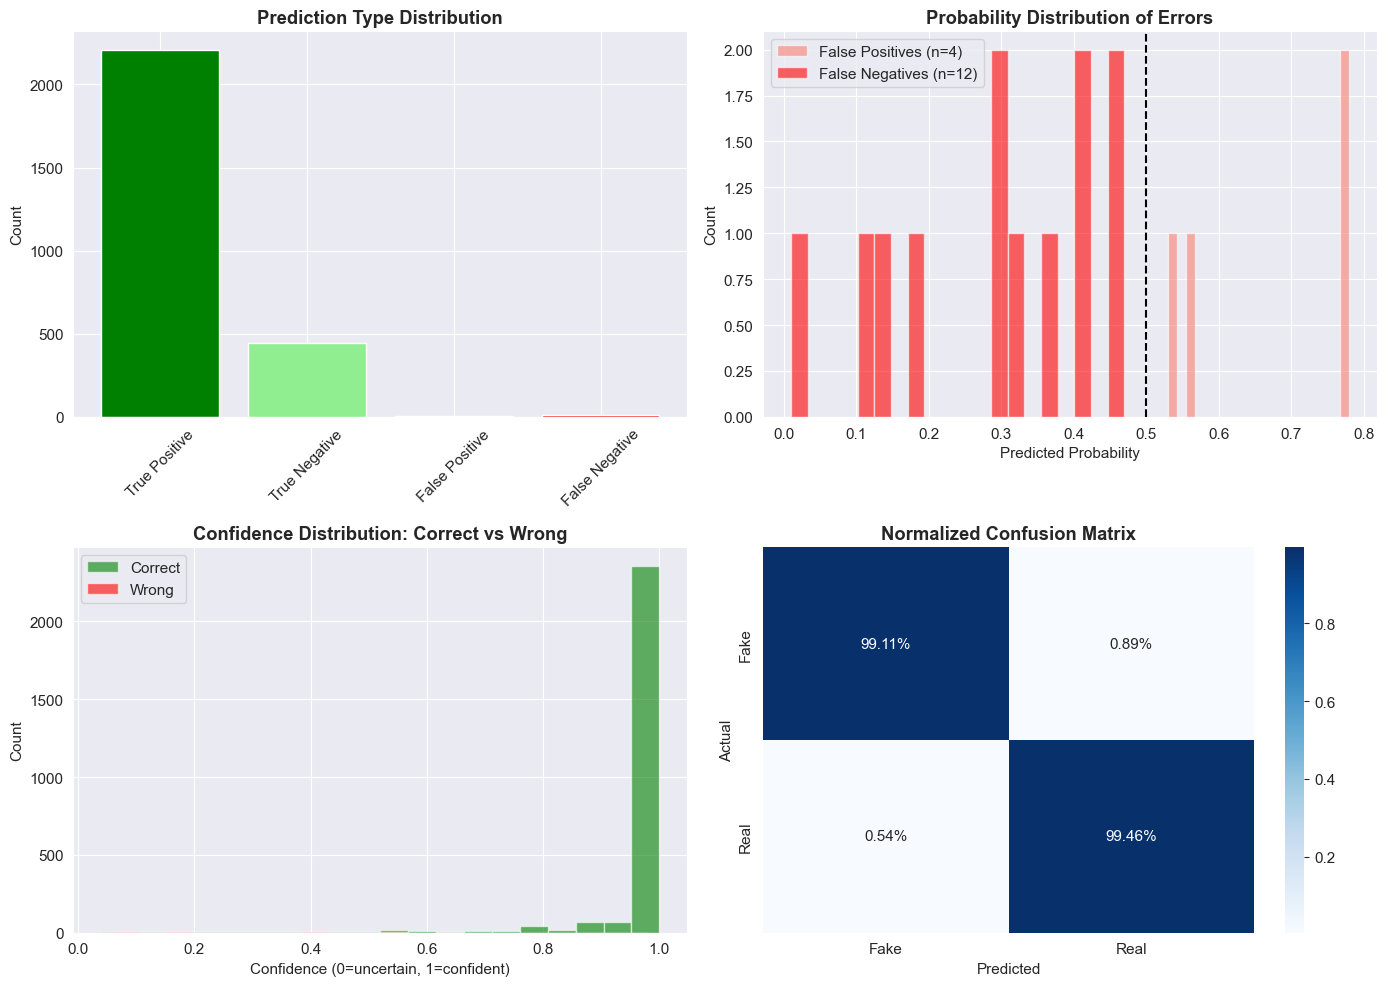

In [ ]:
# Visualiser la distribution des erreurs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution des types de prédiction
colors = ['green', 'lightgreen', 'salmon', 'red']
pred_types = ['Vrai Positif', 'Vrai Négatif', 'Faux Positif', 'Faux Négatif']
counts = [error_counts.get(pt, 0) for pt in pred_types]

axes[0, 0].bar(pred_types, counts, color=colors)
axes[0, 0].set_title('Distribution des Types de Prédiction', fontweight='bold')
axes[0, 0].set_ylabel('Nombre')
axes[0, 0].tick_params(axis='x', rotation=45)

# Distribution des probabilités pour les erreurs
fp_proba = eval_df[eval_df['type_prediction'] == 'Faux Positif']['y_proba']
fn_proba = eval_df[eval_df['type_prediction'] == 'Faux Négatif']['y_proba']

axes[0, 1].hist(fp_proba, bins=20, alpha=0.6, label=f'Faux Positifs (n={len(fp_proba)})', color='salmon')
axes[0, 1].hist(fn_proba, bins=20, alpha=0.6, label=f'Faux Négatifs (n={len(fn_proba)})', color='red')
axes[0, 1].axvline(x=0.5, color='black', linestyle='--')
axes[0, 1].set_xlabel('Probabilité Prédite')
axes[0, 1].set_ylabel('Nombre')
axes[0, 1].set_title('Distribution des Probabilités des Erreurs', fontweight='bold')
axes[0, 1].legend()

# Confiance des erreurs
eval_df['confiance'] = np.abs(eval_df['y_proba'] - 0.5) * 2  # 0 = incertain, 1 = très confiant

axes[1, 0].hist(eval_df[eval_df['correct']]['confiance'], bins=20, alpha=0.6, label='Correct', color='green')
axes[1, 0].hist(eval_df[~eval_df['correct']]['confiance'], bins=20, alpha=0.6, label='Incorrect', color='red')
axes[1, 0].set_xlabel('Confiance (0=incertain, 1=confiant)')
axes[1, 0].set_ylabel('Nombre')
axes[1, 0].set_title('Distribution de Confiance : Correct vs Incorrect', fontweight='bold')
axes[1, 0].legend()

# Heatmap de la matrice de confusion
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Faux', 'Réel'], yticklabels=['Faux', 'Réel'])
axes[1, 1].set_title('Matrice de Confusion Normalisée', fontweight='bold')
axes[1, 1].set_ylabel('Réel')
axes[1, 1].set_xlabel('Prédit')

plt.tight_layout()
plt.savefig('../outputs/18_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Analyse de Contribution des Caractéristiques

FEATURE CONTRIBUTION ANALYSIS

Features needed for 90% importance: 8 out of 21


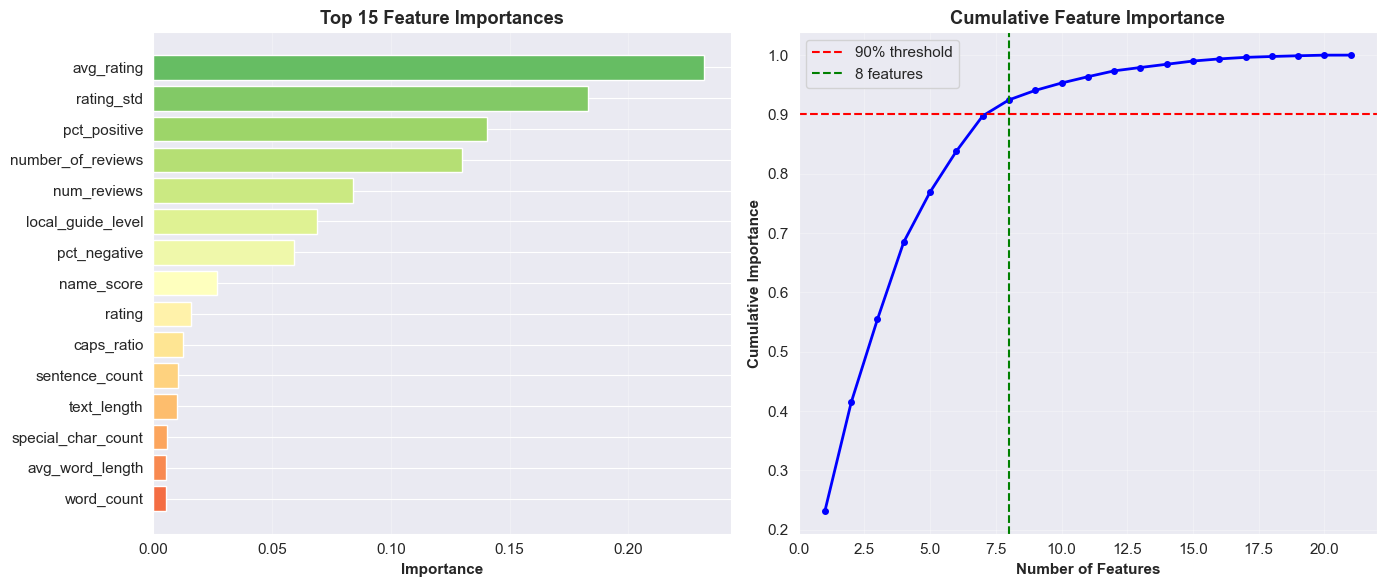


Top 15 Features:


,Feature,Importance,Cumulative,Rank
17,avg_rating,0.2318,0.2318,1
18,rating_std,0.1829,0.4147,2
19,pct_positive,0.1403,0.5550,3
3,number_of_reviews,0.1302,0.6851,4
16,num_reviews,0.0841,0.7692,5
1,local_guide_level,0.0688,0.8380,6
20,pct_negative,0.0595,0.8975,7
2,name_score,0.0271,0.9246,8
0,rating,0.0160,0.9405,9
9,caps_ratio,0.0124,0.9530,10


In [ ]:
print("=" * 80)
print("ANALYSE DE CONTRIBUTION DES CARACTÉRISTIQUES")
print("=" * 80)

# Obtenir l'importance des caractéristiques
feature_importance = pd.DataFrame({
    'Caractéristique': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Importance cumulative
feature_importance['Cumulatif'] = feature_importance['Importance'].cumsum()
feature_importance['Rang'] = range(1, len(feature_importance) + 1)

# Trouver les caractéristiques qui expliquent 90% de l'importance
n_features_90 = (feature_importance['Cumulatif'] <= 0.90).sum() + 1

print(f"\nCaractéristiques nécessaires pour 90% d'importance : {n_features_90} sur {len(feature_cols)}")

# Tracer
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Classement d'importance des caractéristiques
top_n = 15
top_features = feature_importance.head(top_n)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, top_n))[::-1]

axes[0].barh(range(top_n), top_features['Importance'].values, color=colors)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_features['Caractéristique'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance', fontweight='bold')
axes[0].set_title(f'Top {top_n} des Importances de Caractéristiques', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Importance cumulative
axes[1].plot(feature_importance['Rang'], feature_importance['Cumulatif'], 'b-o', linewidth=2, markersize=4)
axes[1].axhline(y=0.9, color='r', linestyle='--', label='Seuil 90%')
axes[1].axvline(x=n_features_90, color='g', linestyle='--', label=f'{n_features_90} caractéristiques')
axes[1].set_xlabel('Nombre de Caractéristiques', fontweight='bold')
axes[1].set_ylabel('Importance Cumulative', fontweight='bold')
axes[1].set_title('Importance Cumulative des Caractéristiques', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/19_feature_contribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Afficher les meilleures caractéristiques
print("\nTop 15 des Caractéristiques :")
display(feature_importance.head(15).round(4))

## Rapport d'Évaluation Final

In [ ]:
print("=" * 80)
print("RAPPORT D'ÉVALUATION FINAL")
print("=" * 80)

brier = brier_score_loss(y_test, y_proba)

report = f"""
RÉSUMÉ DE L'ÉVALUATION DU MODÈLE
================================

Modèle : {type(best_model).__name__}
Taille de l'ensemble de test : {len(y_test)} échantillons

MÉTRIQUES DE PERFORMANCE :
--------------------------
  Exactitude :           {accuracy_score(y_test, y_pred):.4f}
  Exactitude Équilibrée : {balanced_accuracy_score(y_test, y_pred):.4f}
  Précision :            {precision_score(y_test, y_pred):.4f}
  Rappel :               {recall_score(y_test, y_pred):.4f}
  Score F1 :             {f1_score(y_test, y_pred):.4f}
  ROC-AUC :              {roc_auc_score(y_test, y_proba):.4f}
  Précision Moyenne :    {average_precision_score(y_test, y_proba):.4f}

VALIDATION CROISÉE (10-Fold) :
------------------------------
  Score F1 : {cv_results['f1']['mean']:.4f} (+/- {cv_results['f1']['std']*2:.4f})
  ROC-AUC : {cv_results['roc_auc']['mean']:.4f} (+/- {cv_results['roc_auc']['std']*2:.4f})

ANALYSE DES ERREURS :
---------------------
  Vrais Positifs :   {tp}
  Vrais Négatifs :   {tn}
  Faux Positifs :    {fp} (Erreur Type I)
  Faux Négatifs :    {fn} (Erreur Type II)

TOP 5 DES CARACTÉRISTIQUES :
----------------------------
"""

for i, (feat, imp) in enumerate(zip(feature_importance['Caractéristique'].head(5), 
                                     feature_importance['Importance'].head(5)), 1):
    report += f"  {i}. {feat}: {imp:.4f}\n"

report += f"""
OBSERVATIONS DU MODÈLE :
------------------------
  - Les courbes d'apprentissage montrent une {'bonne' if gap < 0.05 else 'moyenne' if gap < 0.1 else 'faible'} généralisation
  - Le modèle est {'bien' if brier < 0.1 else 'acceptablement' if brier < 0.25 else 'mal'} calibré (Brier={brier:.4f})
  - {n_features_90} caractéristiques expliquent 90% de l'importance du modèle

FICHIERS GÉNÉRÉS :
------------------
  - outputs/evaluation_metrics.csv
  - outputs/13_cv_analysis.png
  - outputs/14_learning_curves.png
  - outputs/15_pr_roc_curves.png
  - outputs/16_threshold_analysis.png
  - outputs/17_calibration_analysis.png
  - outputs/18_error_analysis.png
  - outputs/19_feature_contribution.png
"""

print(report)

# Sauvegarder le rapport
with open('../outputs/evaluation_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\nRapport sauvegardé dans outputs/evaluation_report.txt")
print("\n" + "=" * 80)
print("ÉVALUATION DU MODÈLE TERMINÉE !")
print("=" * 80)

FINAL EVALUATION REPORT

MODEL EVALUATION SUMMARY

Model: RandomForestClassifier
Test Set Size: 2671 samples

PERFORMANCE METRICS:
--------------------
  Accuracy:          0.9940
  Balanced Accuracy: 0.9929
  Precision:         0.9982
  Recall:            0.9946
  F1-Score:          0.9964
  ROC-AUC:           0.9993
  Average Precision: 0.9999

CROSS-VALIDATION (10-Fold):
---------------------------
  F1-Score: 0.9951 (+/- 0.0033)
  ROC-AUC:  0.9995 (+/- 0.0007)

ERROR ANALYSIS:
---------------
  True Positives:  2209
  True Negatives:  446
  False Positives: 4 (Type I Error)
  False Negatives: 12 (Type II Error)

TOP 5 FEATURES:
---------------
  1. avg_rating: 0.2318
  2. rating_std: 0.1829
  3. pct_positive: 0.1403
  4. number_of_reviews: 0.1302
  5. num_reviews: 0.0841

MODEL INSIGHTS:
---------------
  - Learning curves show good generalization
  - Model is well calibrated (Brier=0.0067)
  - 8 features explain 90% of model importance

FILES GENERATED:
----------------
  - output